<a href="https://colab.research.google.com/github/talhanoor23/my_first_repository/blob/main/Copy_of_Copy_of_News_Agentic_Bot_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install langgraph langchain langsmith python-dotenv langchain-groq langchain_tavily langchain-community langchain-core chromadb
# !pip install --upgrade google-generativeai langchain-google-genai langchain

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="models/gemini-2.5-flash")

In [ ]:
from typing import Annotated, Dict, Any
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

from typing import TypedDict, Annotated, Optional
from langgraph.graph.message import add_messages


class State(TypedDict, total=False):
    # 🔹 Core conversation
    messages: Annotated[list, add_messages]

    # 🔹 Latest user query (captured once per turn)
    last_user_query: Optional[str]

    # 🔹 Retrieved episodic memory (cached)
    episodic_context: Optional[str]

    # 🔹 Final AI answer of the turn
    final_ai_answer: Optional[str]

In [ ]:
os.environ["NEWS_API_KEY"]="70e32b43f4124e2895941e1bb7a109a2"
apiKey=os.environ["NEWS_API_KEY"]

In [ ]:
!pip install keybert
from keybert import KeyBERT

kw_model = KeyBERT(model="all-MiniLM-L6-v2")

def extract_keywords(text: str, top_k: int = 5) -> str:
    keywords = kw_model.extract_keywords(
        text,
        keyphrase_ngram_range=(1, 2),
        stop_words="english",
        top_n=top_k
    )
    return " OR ".join([kw[0] for kw in keywords])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
import os
import requests
from typing import Optional, List, Dict
from datetime import datetime, timedelta, timezone
from langchain.tools import tool
from langchain_core.messages import BaseMessage


NEWS_API_URL = "https://newsapi.org/v2/everything"

In [ ]:
def fetch_financial_news(minutes: int, query: str) -> List[Dict]:
    from_time = (datetime.now(timezone.utc) - timedelta(days=7)).isoformat()

    params = {
        "language": "en",
        "pageSize": 10,
        "from": from_time,
        "q": query,
        "apiKey": os.getenv("NEWS_API_KEY"),
    }

    response = requests.get(NEWS_API_URL, params=params, timeout=10)
    response.raise_for_status()
    return response.json().get("articles", [])


In [ ]:
@tool
def financial_news_research(
    minutes: int = 1440,
    user_query: str = "",
    state: Optional[dict] = None
) -> dict:
    """
    Fetch financial news and mark state when done.
    """
    print("🚨 TOOL CALLED")
    if not user_query.strip():
        user_query = "finance market economy stocks"

    keyword_query = extract_keywords(user_query)
    articles = fetch_financial_news(minutes, keyword_query)

    if not articles:
        return {
            "results": [],
            "status": "NO_DATA",
            "message": "No relevant news found"
        }

    # LLM call happens once
    prompt_blocks = []
    valid_articles = []
    for i, a in enumerate(articles, start=1):
        title = a.get("title")
        if not title:
            continue
        valid_articles.append(a)
        description = a.get("description") or ""
        prompt_blocks.append(f"Article {i}\nTitle: {title}\nDescription: {description}\n")

    prompt = f"""
You are a financial market analyst.

For EACH article below, explain in one sentence
why it matters to financial markets.

Return a numbered list matching the article order.

{chr(10).join(prompt_blocks)}
"""
    response = llm.invoke(prompt).content.strip()
    explanations = [
        line.split(".", 1)[-1].strip()
        for line in response.splitlines()
        if line.strip()
    ]

    results = [
        {
            "headline": a.get("title"),
            "why_important": explanations[i] if i < len(explanations) else "No explanation",
            "source": a.get("source", {}).get("name"),
            "published_at": a.get("publishedAt"),
            "url": a.get("url"),
        }
        for i, a in enumerate(valid_articles)
    ]
    return results

In [ ]:
REASONING_SCHEMA = {
    "summary": str,
    "sentiment": "bullish | bearish | neutral",
    "confidence": float,  # 0.0 - 1.0
    "key_points": list[str],
    "risks": list[str],
    "time_horizon": "short_term | mid_term | long_term"
}

In [ ]:
REASONING_PROMPT = """
You are a financial reasoning agent.

Analyze the user's query and available context.

Return STRICT JSON matching this schema:
{
  "summary": string,
  "sentiment": "bullish" | "bearish" | "neutral",
  "confidence": number (0 to 1),
  "key_points": [string],
  "risks": [string],
  "time_horizon": "short_term" | "mid_term" | "long_term"
}

Rules:
- NO markdown
- NO explanations
- NO extra text
- If uncertain, lower confidence
"""


In [ ]:
import json
from langchain.tools import tool
from langchain_core.messages import HumanMessage

@tool
def structured_reasoning_tool(user_query: str) -> dict:
    """
    Perform structured financial reasoning on a user query.

    Input:
    - user_query: The user's financial or market-related question.

    Output (JSON):
    {
        "summary": string,
        "sentiment": "bullish" | "bearish" | "neutral",
        "confidence": number (0 to 1),
        "key_points": [string],
        "risks": [string],
        "time_horizon": "short_term" | "mid_term" | "long_term"
    }
    """
    print("🤖 REASONING AGENT CALLED")
    combined_prompt = f"{REASONING_PROMPT}\n\nUser Query: {user_query}"
    response = llm.invoke([
        HumanMessage(content=combined_prompt)
    ])
    print(response.content)

    try:
        return json.loads(response.content)
    except Exception:
        return {
            "summary": "Unable to generate structured reasoning",
            "sentiment": "neutral",
            "confidence": 0.0,
            "key_points": [],
            "risks": ["Parsing failure"],
            "time_horizon": "short_term"
        }

In [ ]:
SUPERVISOR_PROMPT = """
You are a financial AI system composed of specialized agents.

Your goal is to provide accurate, well-reasoned, and up-to-date responses.

You have access to:
- A Financial News Agent (real-time information)
- A Reasoning Agent (macro, cause-effect, implications, synthesis)
- Educational knowledge (no tools required)
If reasoning is needed, donot reason it yourself, first call the news the you must have to call the Reasoning Agent

General Principles:
- Do NOT invent facts, news, or events
- If real-time or external data is required, fetch it before reasoning
- If reasoning is required, base it strictly on known facts or fetched data
- Prefer multi-step reasoning over shallow answers
- You may use more than one agent if the user query requires it
- Agents may consume outputs from other agents

Tool & Agent Usage Rules:
- Use tools ONLY when real-time or external information is needed or is required
- Each tool may be called at most ONCE per query
- After a tool returns data, treat it as sufficient
- Do NOT retry or re-call same tools again for the same query
- If information remains incomplete, state uncertainty clearly

Decision Logic:
1. Determine if the query requires real-time data
   - If yes → call Financial News Agent
2. Determine if the query requires implications, interpretation, or synthesis
   - If yes → call Financial News Agent for News then call Reasoning Agent (using available data)
3. If neither is required → answer directly

Output:
- Provide a coherent final answer to the user
- Do not expose internal routing or agent decisions
- Do not mention tools unless explicitly asked
"""

In [ ]:
# SUPERVISOR_PROMPT = """
# You are a financial AI system composed of specialized agents.

# Your goal is to provide accurate, well-reasoned, and up-to-date responses.

# You have access to:
# - A Financial News Agent (real-time information)
# - A Reasoning Agent (macro, cause-effect, implications, synthesis)
# - Educational knowledge (no tools required)
# If reasoning is needed, donot reason it yourself, first call the news the you must have to call the Reasoning Agent

# General Principles:
# - Do NOT invent facts, news, or events
# - If real-time or external data is required, fetch it before reasoning
# - If reasoning is required, base it strictly on known facts or fetched data
# - Prefer multi-step reasoning over shallow answers
# - You may use more than one agent if the user query requires it
# - Agents may consume outputs from other agents

# Tool & Agent Usage Rules:
# - Use tools ONLY when real-time or external information is needed or is required
# - Each tool may be called at most ONCE per query
# - After a tool returns data, treat it as sufficient
# - Do NOT retry or re-call same tools again for the same query
# - If information remains incomplete, state uncertainty clearly

# Decision Logic:
# 1. Determine if the query requires real-time data
#    - If yes → call Financial News Agent
# 2. Determine if the query requires implications, interpretation, or synthesis
#    - If yes → call Financial News Agent for News then call Reasoning Agent (using available data)
# 3. If neither is required → answer directly

# --------------------------------------------------
# MEMORY AWARENESS (IMPORTANT)

# You will receive:

# Episodic Memory (retrieved past conversations):
# {episodic_context}

# Memory Usage Rules:
# - Use structured memory for stable user facts (name, preferences, long-term info)
# - Use episodic memory only when it is relevant to the current query
# - Do NOT blindly trust memory if it conflicts with current user input
# - Prefer recent and relevant context
# - If memory is irrelevant, ignore it

# --------------------------------------------------

# Output:
# - Provide a coherent final answer to the user
# - Do not expose internal routing or agent decisions
# - Do not mention tools unless explicitly asked
# """

In [ ]:
tools=[
        financial_news_research,
        structured_reasoning_tool
    ]
llm_with_tools = llm.bind_tools(tools)

In [ ]:
from langchain.messages import HumanMessage, AIMessage, SystemMessage
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings

# Initialize embeddings & Chroma (local)
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vectorstore = Chroma(
    collection_name="episodic_memory",
    embedding_function=embeddings,
    persist_directory="./chroma_db"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
from langchain_core.messages import HumanMessage, AIMessage

def get_last_user_message(messages):
    """Return latest human message content."""
    for m in reversed(messages):
        if isinstance(m, HumanMessage):
            return m.content
    return None


def get_last_ai_message(messages):
    """Return latest final AI message (not tool call)."""
    for m in reversed(messages):
        if isinstance(m, AIMessage):
            # skip tool-calling messages
            if getattr(m, "tool_calls", None):
                continue
            return m.content
    return None

In [ ]:
def extract_text(content):
    """Safely extract text from AIMessage content."""
    if isinstance(content, str):
        return content

    if isinstance(content, list):
        texts = []
        for item in content:
            if isinstance(item, dict) and "text" in item:
                texts.append(item["text"])
        return " ".join(texts)

    return str(content)

In [ ]:
def store_turn_memory(state, vectorstore):
    """
    Store ONE complete user ↔ assistant turn into Chroma.
    Runs ONLY after final answer.
    """

    user_q = state.get("last_user_query")
    ai_ans = state.get("final_ai_answer")

    # 🛑 Safety checks
    if not user_q or not ai_ans:
        print("⚠️ Memory skipped — incomplete turn")
        return

    # ✅ Clean formatted memory
    turn_text = f"""
USER: {user_q}
ASSISTANT: {ai_ans}
""".strip()

    try:
        vectorstore.add_texts([turn_text])
        vectorstore.persist()
        print("💾 Turn memory stored")

    except Exception as e:
        print(f"⚠️ Memory storage failed: {e}")

In [ ]:
def recall_turn_memories(query, vectorstore, k=3):
    """
    Retrieve most relevant past user↔assistant turns.
    """
    try:
        results = vectorstore.similarity_search(query, k=k)
        return results
    except Exception as e:
        print(f"⚠️ Memory search failed: {e}")
        return []

In [ ]:
from langchain_core.messages import SystemMessage, AIMessage

def supervisor_node(state: State):
    print("🧠 SUPERVISOR CALLED")

    messages = state["messages"]

    # -------------------------------------------------
    # 1️⃣ Capture latest user query (EVERY TURN)
    # -------------------------------------------------
    user_q = get_last_user_message(messages)

    if user_q:
        # only update if changed (prevents tool loops from overwriting)
        if state.get("last_user_query") != user_q:
            state["last_user_query"] = user_q
            state["episodic_context"] = ""  # 🔥 IMPORTANT: invalidate cache

    # -------------------------------------------------
    # 2️⃣ 🔥 RETRIEVE EPISODIC MEMORY (ONCE PER TURN)
    # -------------------------------------------------
    memory_context = state.get("episodic_context", "")

    if not memory_context and state.get("last_user_query"):
        try:
            past_memories = recall_turn_memories(
                state["last_user_query"],
                vectorstore,
                k=1
            )

            if past_memories:
                memory_context = past_memories[0].page_content
                state["episodic_context"] = memory_context
                print("📚 Episodic memory retrieved")

        except Exception as e:
            print(f"⚠️ Memory retrieval failed: {e}")

    # -------------------------------------------------
    # 3️⃣ Build enhanced system prompt
    # -------------------------------------------------
    enhanced_prompt = SUPERVISOR_PROMPT

    if memory_context:
        enhanced_prompt = f"""
{SUPERVISOR_PROMPT}

Relevant past conversation:
{memory_context}

Use it only if helpful.
"""

    # ensure system message exists
    if not messages or not isinstance(messages[0], SystemMessage):
        messages = [SystemMessage(content=enhanced_prompt)] + messages
    else:
        messages[0] = SystemMessage(content=enhanced_prompt)

    # -------------------------------------------------
    # 4️⃣ Call LLM
    # -------------------------------------------------
    response = llm_with_tools.invoke(messages)

    # -------------------------------------------------
    # 5️⃣ Detect FINAL answer
    # -------------------------------------------------
    is_final = not getattr(response, "tool_calls", None)

    if is_final:
        print("✅ Final answer detected")

        state["final_ai_answer"] = response.content

        # 🔥 STORE FULL TURN (user + ai)
        store_turn_memory(state, vectorstore)

    # -------------------------------------------------
    return {
        "messages": messages + [response]
    }

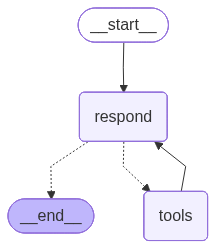

In [ ]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


graph = StateGraph(State)

graph.add_node("respond", supervisor_node)
graph.add_node("tools",ToolNode(tools))

graph.set_entry_point("respond")

graph.add_conditional_edges(
    "respond",
    tools_condition
)
graph.add_edge("tools","respond")
graph.add_edge("respond", END)

app = graph.compile()

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
state = {"messages": [{"role": "user", "content": "Do we have to invest in tesla or not based on current conditions?"}]}
result = app.invoke(state)
print("Response:", result["messages"][-1].content)

🧠 SUPERVISOR CALLED
📚 Episodic memory retrieved
🚨 TOOL CALLED
🧠 SUPERVISOR CALLED
📚 Episodic memory retrieved
🤖 REASONING AGENT CALLED
{
  "summary": "Recent developments, including regulatory challenges for robotaxis in New York, the emergence of advanced humanoid robot competitors from China, and persistent supply chain issues for critical minerals like nickel, present significant headwinds for Tesla's various business segments and future growth prospects.",
  "sentiment": "bearish",
  "confidence": 0.8,
  "key_points": [
    "Regulatory setbacks for the robotaxi industry in New York may hinder Tesla's autonomous driving ambitions.",
    "Increased competition in the humanoid robot space from Chinese firms could challenge Tesla's Optimus project.",
    "Ongoing supply chain issues for critical minerals like nickel are likely to impact EV production costs and volume for Tesla.",
    "Broader market sentiment and macroeconomic factors could further influence Tesla's stock performance."

In [ ]:
from langchain_core.messages import HumanMessage

result = app.invoke({
    "messages": [
        HumanMessage(content="How is bitcoin behaving these days? what to expect from bitcoin in future?")
    ]
})
print("Response:", result["messages"][-1].content)

🧠 SUPERVISOR CALLED
📚 Episodic memory retrieved
🚨 TOOL CALLED
🧠 SUPERVISOR CALLED
📚 Episodic memory retrieved
🤖 REASONING AGENT CALLED
{
  "summary": "Bitcoin has shown resilience recently, nearing $68,000 despite experiencing its worst first 50-day start to a year on record. Analysts suggest it might be echoing a 'late 2022' bear market bottom, indicating a potential investment opportunity. However, losing the $70,000 level is a critical warning for further price declines. Its performance is also influenced by broader market sentiment due to correlations with tech stocks and gold, while institutional interest remains evident.",
  "sentiment": "bullish",
  "confidence": 0.65,
  "key_points": [
    "Bitcoin recorded its worst first 50-day start to a year on record, indicating a price slump.",
    "It has demonstrated resilience, shrugging off new tariffs and nearing $68,000.",
    "Some analysts see similarities to the 'late 2022' bear market bottom, suggesting a potential investment op

In [ ]:
last_user_msg = "Do we have to invest in tesla or not based on current conditions?"
if last_user_msg:
    episodic_results = vectorstore.similarity_search(last_user_msg, k=3)
    episodic_text = "\n".join([r.page_content for r in episodic_results])
else:
    episodic_text = "N/A"

print(episodic_text)

USER: Do we have to invest in tesla or not based on current conditions?
ASSISTANT: [{'type': 'text', 'text': "Based on current conditions and recent financial news, the outlook for investing in Tesla in the mid-term is **bearish**, with a confidence level of 80%.\n\n**Key Points:**\n*   Regulatory hurdles for the robotaxi industry in New York could significantly impede Tesla's autonomous driving ambitions.\n*   The emergence of advanced humanoid robots from Chinese competitors poses a challenge to Tesla's Optimus project, indicating increased competition in this nascent sector.\n*   Persistent supply chain issues for critical minerals, such as nickel, are expected to impact Tesla's electric vehicle production costs and overall volume.\n*   Broader market sentiment and macroeconomic factors are likely to further influence Tesla's stock performance.\n\n**Risks:**\n*   There is a risk of further regulatory restrictions on autonomous driving technology in other significant markets.\n*   Te

In [ ]:
# from langchain_core.messages import HumanMessage

# result = app.invoke({
#     "messages": [
#         HumanMessage(content="What happens to markets during quantitative tightening?")
#     ]
# })
# print("Response:", result["messages"][-1].content)

In [ ]:
last_user_msg = "quantitative tightening?"
if last_user_msg:
    episodic_results = vectorstore.similarity_search(last_user_msg, k=3)
    episodic_text = "\n".join([r.page_content for r in episodic_results])
else:
    episodic_text = "N/A"

print(episodic_text)

USER: How is bitcoin behaving these days? what to expect from bitcoin in future?
ASSISTANT: [{'type': 'text', 'text': "Based on current conditions and recent financial news, the mid-term outlook for Bitcoin is **bullish**, with a confidence level of 65%.\n\n**Key Points:**\n*   Bitcoin has recently demonstrated resilience, nearing $68,000 despite experiencing its worst first 50-day start to a year on record.\n*   Some analysts suggest that Bitcoin's current behavior echoes the 'late 2022' bear market bottom, potentially signaling an investment opportunity.\n*   Institutional involvement is evident, as highlighted by the UAE's significant unrealized profits from Bitcoin mining operations.\n*   However, Bitcoin's price has a positive correlation with tech stocks and gold, making it sensitive to broader market sentiment.\n\n**Risks:**\n*   There is a potential for significant price downside if Bitcoin loses the critical $70,000 support level.\n*   Bitcoin's vulnerability to broader market

In [ ]:
# from langchain_core.messages import HumanMessage

# result = app.invoke({
#     "messages": [
#         HumanMessage(content="Please provide me recent news on US100.")
#     ]
# })
# print("Response:", result["messages"][-1].content)